# GSE182127 AReST reproduction

This notebook recomputes AReST scores from the repository `.h5ad` file, applies max-statistic permutation thresholding, extracts the anomalous region with DBSCAN, and evaluates the result against the author Leiden cluster 10/12 reference region.

## Inputs and settings

The `.h5ad` file is read from `data/`. The author Leiden/anatomy annotation is used only to define the reference region and to draw anatomical background labels.

In [1]:
from pathlib import Path
import sys

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "notebooks"))

from gse182127 import MethodConfig, RegionConfig, run_gse182127_reproduction

DATA_H5AD = REPO / "data" / "GSE182127_all_samples_aligned_to_GSM5519060_sham_combined.h5ad"
ANNOTATION = REPO / "data" / "author_leiden_clusters_heme1000.csv"
OUT = REPO / "results" / "gse182127_reproduction"

method_config = MethodConfig(
    n_top_hvg=2000,
    n_pc=30,
    k_expr=80,
    sigma_quantile=0.60,
    n_perm=1000,
    alpha=0.05,
    seed=0,
)
region_config = RegionConfig(min_samples=7, min_cluster_size=20)

print(DATA_H5AD.relative_to(REPO))
print(ANNOTATION.relative_to(REPO))
print(method_config)
print(region_config)

data/GSE182127_all_samples_aligned_to_GSM5519060_sham_combined.h5ad
data/author_leiden_clusters_heme1000.csv
MethodConfig(n_top_hvg=2000, n_pc=30, k_expr=80, sigma_quantile=0.6, n_perm=1000, alpha=0.05, seed=0)
RegionConfig(min_samples=7, min_cluster_size=20)


## Run AReST

In [2]:
result = run_gse182127_reproduction(
    h5ad_path=DATA_H5AD,
    annotation_csv=ANNOTATION,
    output_dir=OUT,
    method_config=method_config,
    region_config=region_config,
)
result["metrics"]

,metric,value
0,AUROC,0.972248
1,AUPRC,0.922910
2,Moran_I,0.936843
3,Region_precision,0.746102
4,Region_recall,0.951705
5,Region_Jaccard,0.718884
6,Region_Dice,0.836454
7,Region_size,898.000000
8,Reference_region_size,704.000000
9,Region_overlap,670.000000


## Key summary

In [3]:
summary = result["summary"]
for key in [
    "sigma", "tau_high", "n_significant", "eps", "n_clusters_retained",
    "retained_cluster_sizes", "Region_size", "Reference_region_size",
    "Region_overlap", "Region_precision", "Region_recall", "Region_Jaccard",
    "AUROC", "AUPRC", "Moran_I",
]:
    print(f"{key}: {summary[key]}")

sigma: 780.5726574536
tau_high: 0.3551698486
n_significant: 1121
eps: 83.7257427557
n_clusters_retained: 1
retained_cluster_sizes: [898]
Region_size: 898.0
Reference_region_size: 704.0
Region_overlap: 670.0
Region_precision: 0.7461024499
Region_recall: 0.9517045455
Region_Jaccard: 0.7188841202
AUROC: 0.9722477667
AUPRC: 0.9229096818
Moran_I: 0.9368433442


## Figures

arest_score_map.png


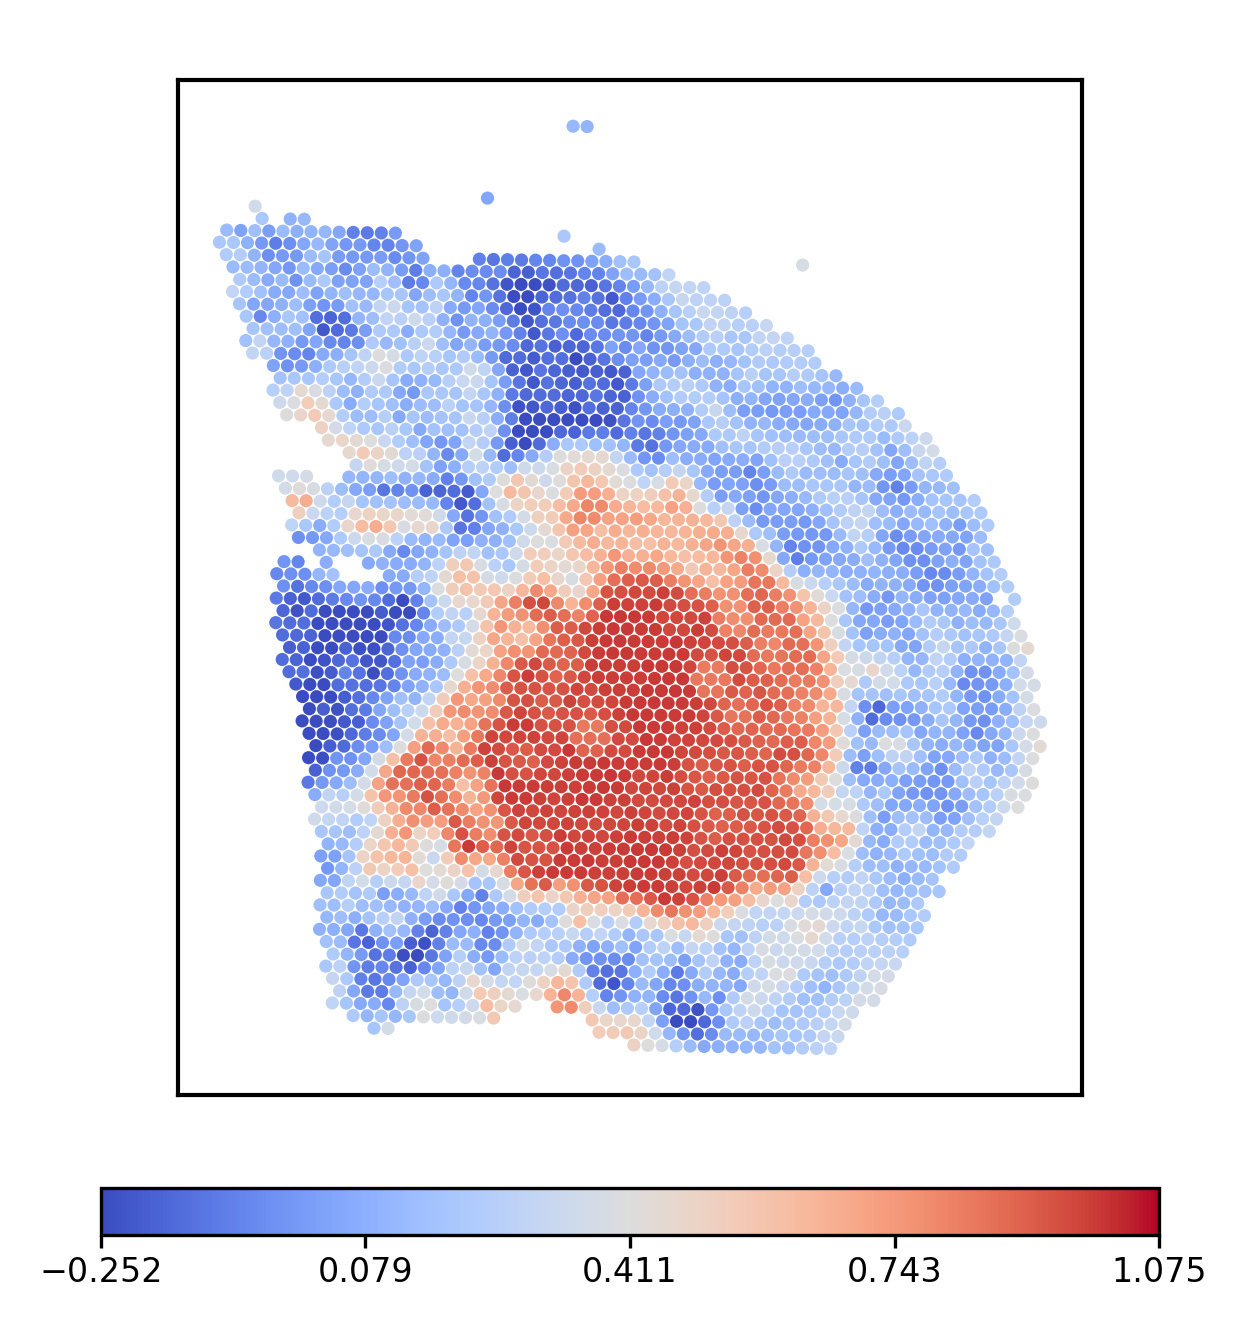

reference_region_map.png


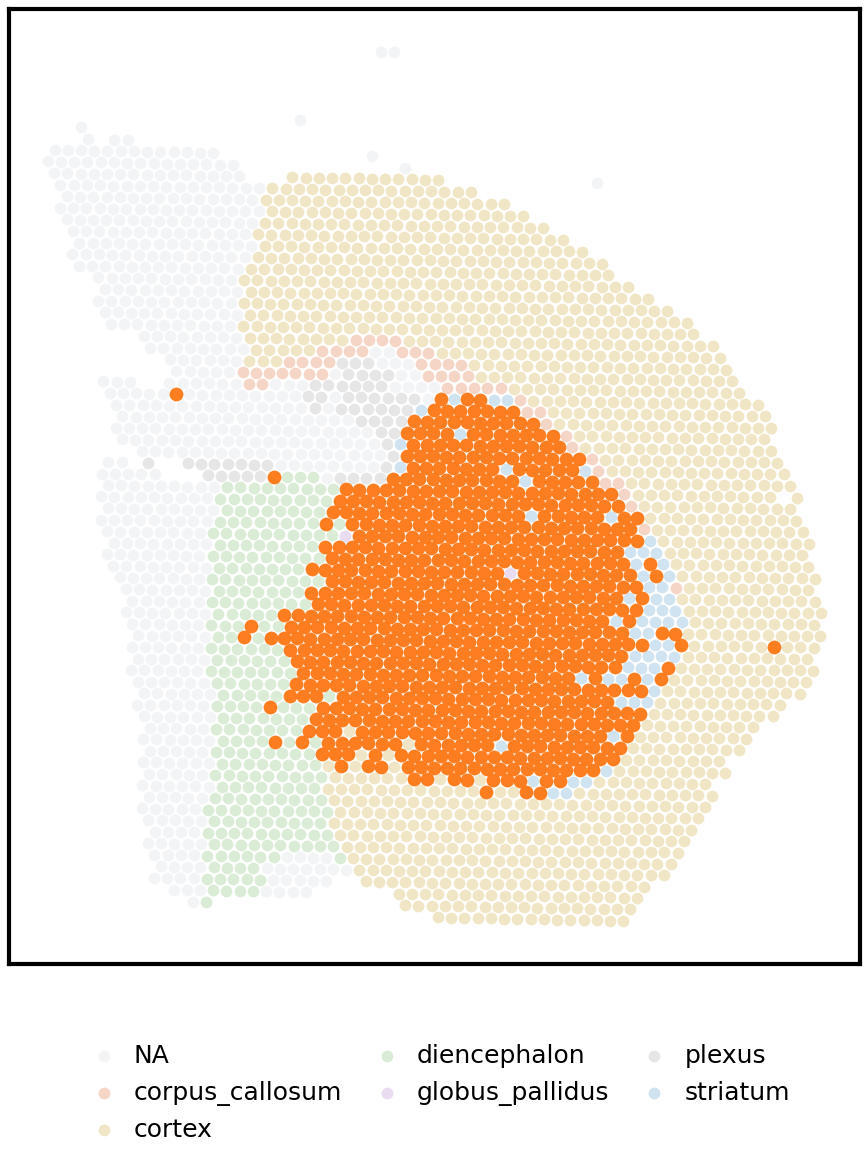

arest_region_map.png


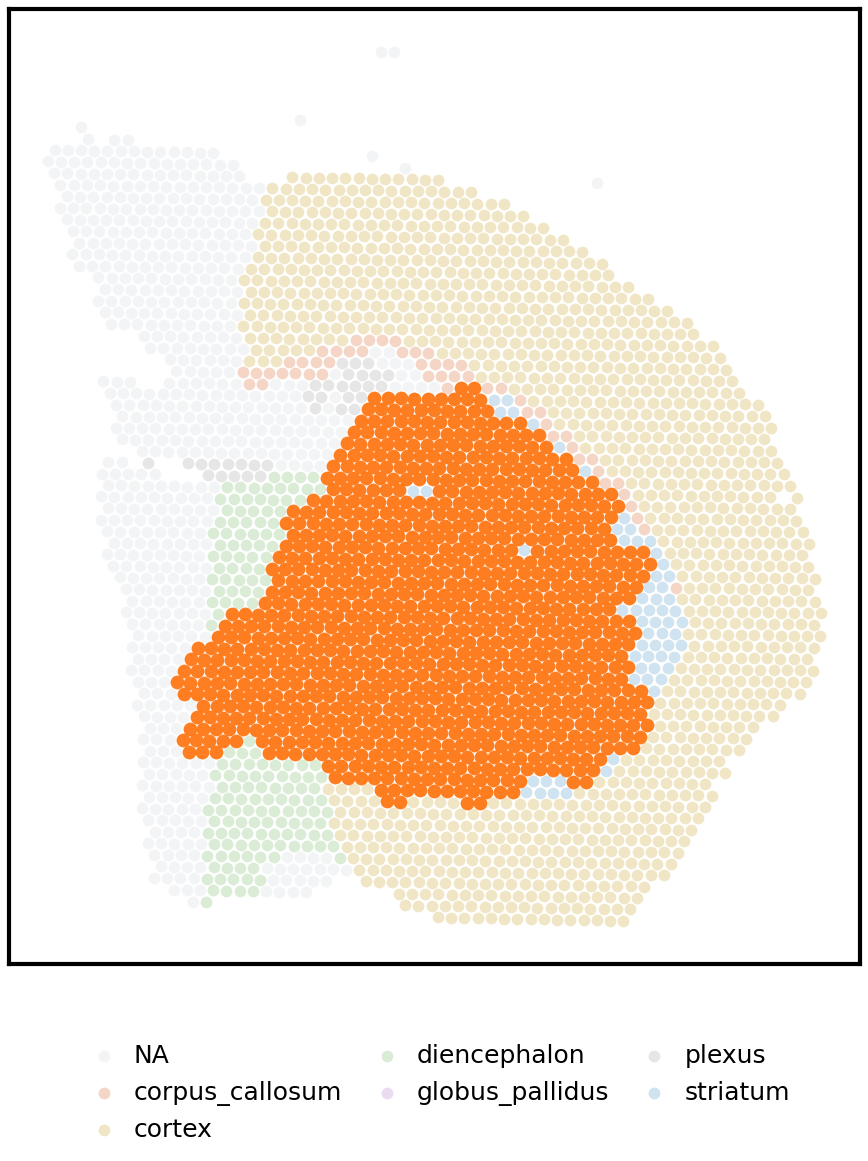

In [4]:
from IPython.display import Image, display

for name in ["arest_score_map.png", "reference_region_map.png", "arest_region_map.png"]:
    print(name)
    display(Image(filename=str(OUT / "figures" / name)))

Output tables and figures are written to `results/gse182127_reproduction/`.